In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/GCB2022v27_MtCO2_flat.csv')
display(df.head())

,Country,ISO 3166-1 alpha-3,Year,Total,Coal,Oil,Gas,Cement,Flaring,Other,Per Capita
0,Afghanistan,AFG,1750,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,1751,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1752,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,1753,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,1754,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
import io

In [10]:
df = df.drop(columns=["Other"])


In [11]:
emission_columns = ["Coal", "Oil", "Gas", "Cement", "Flaring"]


In [12]:
df[emission_columns] = df[emission_columns].fillna(0)


In [13]:
df.dropna(inplace=True)


In [14]:
print("Data Cleaning Complete. Here's a summary of the cleaned data:")
print(df.info())
print("\nFirst 5 Rows of the Cleaned Data:")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

Data Cleaning Complete. Here's a summary of the cleaned data:
<class 'pandas.core.frame.DataFrame'>
Index: 18542 entries, 200 to 63103
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             18542 non-null  object 
 1   ISO 3166-1 alpha-3  18542 non-null  object 
 2   Year                18542 non-null  int64  
 3   Total               18542 non-null  float64
 4   Coal                18542 non-null  float64
 5   Oil                 18542 non-null  float64
 6   Gas                 18542 non-null  float64
 7   Cement              18542 non-null  float64
 8   Flaring             18542 non-null  float64
 9   Per Capita          18542 non-null  float64
dtypes: float64(7), int64(1), object(2)
memory usage: 1.6+ MB
None

First 5 Rows of the Cleaned Data:
| Country     | ISO 3166-1 alpha-3   | Year   | Total    | Coal     | Oil      | Gas   | Cement   | Flaring   | Per Capita   |
|:------------|

In [16]:
features = [
    "Year", "Coal", "Oil", "Gas", "Cement", "Flaring"
]
X = df[features]

In [17]:
target = "Total"
y = df[target]

In [18]:
print("Input Features (X):")
print(X.head().to_markdown(index=False, numalign="left", stralign="left"))

Input Features (X):
| Year   | Coal     | Oil      | Gas   | Cement   | Flaring   |
|:-------|:---------|:---------|:------|:---------|:----------|
| 1950   | 0.021068 | 0.063204 | 0     | 0        | 0         |
| 1951   | 0.025648 | 0.065952 | 0     | 0        | 0         |
| 1952   | 0.031708 | 0.059892 | 0     | 0        | 0         |
| 1953   | 0.037949 | 0.068307 | 0     | 0        | 0         |
| 1954   | 0.042502 | 0.063754 | 0     | 0        | 0         |


In [19]:
print("\nTarget Variable (y):")
print(y.head().to_markdown(numalign="left", stralign="left"))


Target Variable (y):
|     | Total    |
|:----|:---------|
| 200 | 0.084272 |
| 201 | 0.0916   |
| 202 | 0.0916   |
| 203 | 0.106256 |
| 204 | 0.106256 |


In [20]:
from sklearn.model_selection import train_test_split


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
print("Training Data Size:")
print(f"X_train (Features): {X_train.shape}")
print(f"y_train (Target): {y_train.shape}")

print("\nTesting Data Size:")
print(f"X_test (Features): {X_test.shape}")
print(f"y_test (Target): {y_test.shape}")

Training Data Size:
X_train (Features): (14833, 6)
y_train (Target): (14833,)

Testing Data Size:
X_test (Features): (3709, 6)
y_test (Target): (3709,)


In [23]:
from sklearn.linear_model import LinearRegression


In [24]:
model = LinearRegression()


In [25]:
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [26]:
from sklearn.metrics import mean_squared_error, r2_score


In [27]:
y_pred = model.predict(X_test)


In [28]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [29]:
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 15.84
R-squared (R2): 1.00


In [30]:
y_pred = model.predict(X_test)


In [31]:
predictions_df = pd.DataFrame({'Actual Total': y_test, 'Predicted Total': y_pred})


In [32]:
print("Comparison of Actual vs. Predicted Total Emissions:")
print(predictions_df.head().to_markdown(numalign="left", stralign="left"))

Comparison of Actual vs. Predicted Total Emissions:
|       | Actual Total   | Predicted Total   |
|:------|:---------------|:------------------|
| 7585  | 229.394        | 227.013           |
| 49766 | 7.36213        | 7.70059           |
| 21158 | 7.28646        | 7.27096           |
| 55728 | 12.0541        | 12.1173           |
| 38889 | 6.90466        | 7.19731           |


In [33]:
import matplotlib.pyplot as plt

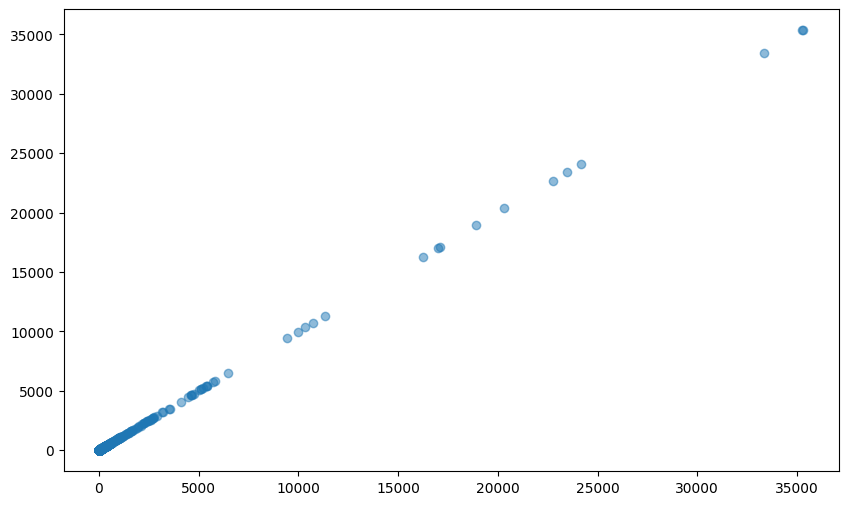

In [34]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

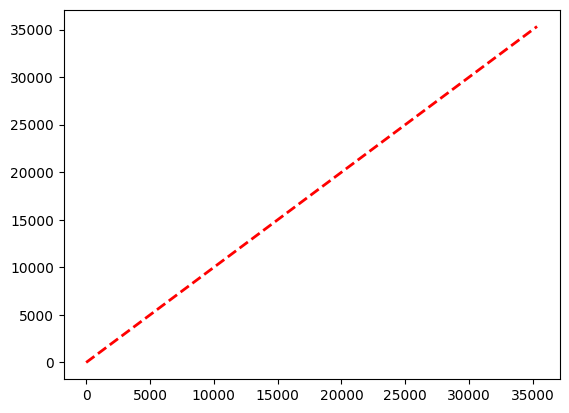

In [35]:
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)


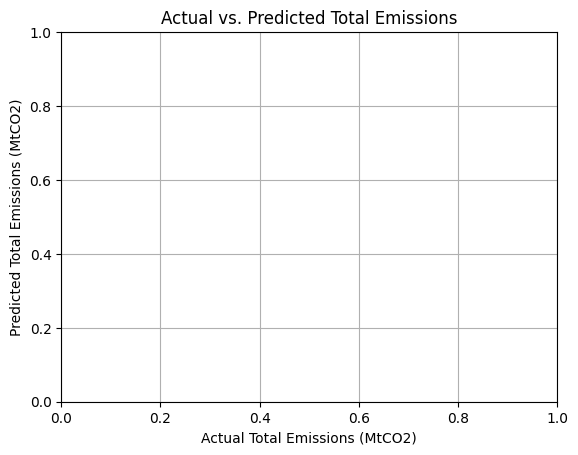

In [36]:
plt.xlabel("Actual Total Emissions (MtCO2)")
plt.ylabel("Predicted Total Emissions (MtCO2)")
plt.title("Actual vs. Predicted Total Emissions")
plt.grid(True)
plt.show()

In [37]:
import joblib


In [38]:
model_filename = 'carbon_footprint_model.pkl'


In [39]:
joblib.dump(model, model_filename)
print(f"Model successfully saved as '{model_filename}'")


Model successfully saved as 'carbon_footprint_model.pkl'
